In [1]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import r2_score as r2
import numpy as np

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [23]:
weight,bias=0.3,0.9
x=torch.arange(0,1,0.01)
y=weight*x+bias

In [24]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=18)
x_train=x_train.unsqueeze(dim=1)
x_test=x_test.unsqueeze(dim=1)
y_train=y_train.unsqueeze(dim=1)
y_test=y_test.unsqueeze(dim=1)

In [15]:
class Linear_Regression(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer=nn.Linear(in_features=1,out_features=1)

    def forward(self,x):
        return self.linear_layer(x)

In [7]:
torch.manual_seed(18)
model=Linear_Regression()
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.0084]])),
             ('linear_layer.bias', tensor([-0.0825]))])

In [16]:
loss_func=nn.L1Loss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [25]:
epochs=10000
for _ in range(epochs):
    model.train()
    y_pred=model(x_train)
    loss=loss_func(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [26]:
model.eval()
with torch.inference_mode():
    y_test_predict=model(x_test)

In [27]:
r2(y_test,y_test_predict)

0.9899473190307617

In [28]:
import seaborn as sns

<Axes: >

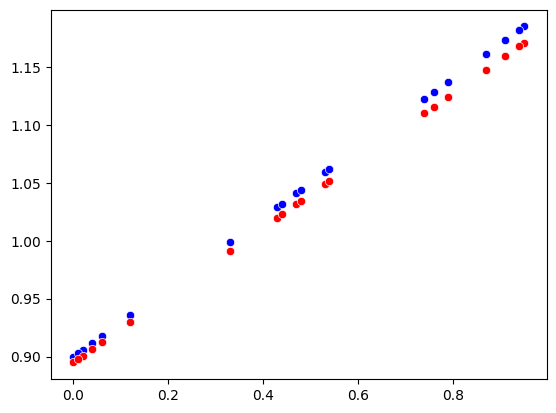

In [39]:
sns.scatterplot(x=x_test.squeeze().numpy(),y=y_test.squeeze().numpy(),color='blue')
sns.scatterplot(x=x_test.squeeze().numpy(),y=y_test_predict.squeeze().numpy(),color='red')

In [40]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.2907]])),
             ('linear_layer.bias', tensor([0.8949]))])

In [41]:
torch.save(model.state_dict(),"Linear_Regression_Model2.pth")

In [42]:
model_new=Linear_Regression()

In [44]:
model_new.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.2079]])),
             ('linear_layer.bias', tensor([0.5043]))])

In [45]:
model_new.load_state_dict(torch.load("Linear_Regression_Model2.pth"))

<All keys matched successfully>

In [46]:
model_new.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.2907]])),
             ('linear_layer.bias', tensor([0.8949]))])